In [10]:
import sys
!{sys.executable} -m pip install xlrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 4.9 MB/s eta 0:00:00


In [11]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")
print("All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [12]:
DESKTOP   = os.path.expanduser("~/Desktop")
FILE_PATH = os.path.join(DESKTOP, "default of credit card clients.xls")

df = pd.read_excel(FILE_PATH, header=1, engine="xlrd")
df = df.drop(columns=["ID"])
df = df.rename(columns={"default payment next month": "default"})

print(f"Data loaded successfully!")
print(f"   Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"   Missing values: {df.isnull().sum().sum()}")
df.head()

✅ Data loaded successfully!
   Rows: 30,000   Columns: 24
   Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Class Distribution
  No Default (0) : 23,364  (77.88%)
  Default    (1) : 6,636  (22.12%)


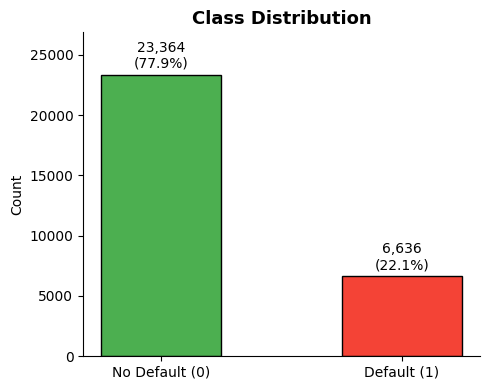

✅ Saved → Desktop/RF_01_class_distribution.png


In [13]:
counts = df["default"].value_counts()
pcts   = df["default"].value_counts(normalize=True) * 100

print("Class Distribution")
print(f"  No Default (0) : {counts[0]:,}  ({pcts[0]:.2f}%)")
print(f"  Default    (1) : {counts[1]:,}  ({pcts[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["No Default (0)", "Default (1)"], counts,
              color=["#4CAF50", "#F44336"], edgecolor="black", width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(DESKTOP, "RF_01_class_distribution.png"), dpi=150)
plt.show()
print("Saved → Desktop/RF_01_class_distribution.png")

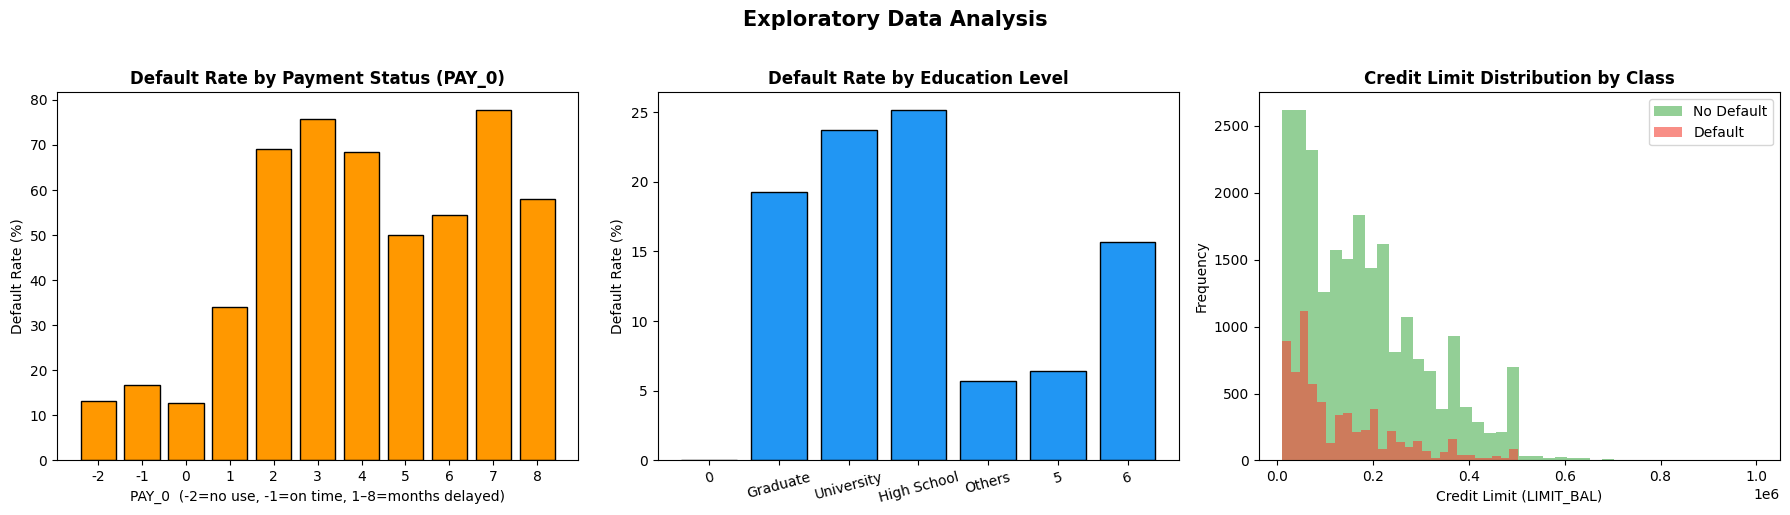

✅ Saved → Desktop/RF_02_eda.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Default rate by PAY_0
pay_dr = df.groupby("PAY_0")["default"].mean() * 100
axes[0].bar(pay_dr.index.astype(str), pay_dr.values,
            color="#FF9800", edgecolor="black")
axes[0].set_title("Default Rate by Payment Status (PAY_0)", fontweight="bold")
axes[0].set_xlabel("PAY_0  (-2=no use, -1=on time, 1–8=months delayed)")
axes[0].set_ylabel("Default Rate (%)")

# (B) Default rate by EDUCATION
edu_labels = {1: "Graduate", 2: "University", 3: "High School", 4: "Others"}
edu_dr = df.groupby("EDUCATION")["default"].mean() * 100
edu_dr.index = [edu_labels.get(i, str(i)) for i in edu_dr.index]
axes[1].bar(edu_dr.index, edu_dr.values, color="#2196F3", edgecolor="black")
axes[1].set_title("Default Rate by Education Level", fontweight="bold")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

# (C) Credit limit distribution by class
df[df["default"] == 0]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#4CAF50", label="No Default")
df[df["default"] == 1]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#F44336", label="Default")
axes[2].set_title("Credit Limit Distribution by Class", fontweight="bold")
axes[2].set_xlabel("Credit Limit (LIMIT_BAL)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.suptitle("Exploratory Data Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DESKTOP, "RF_02_eda.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Desktop/RF_02_eda.png")

In [15]:
X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]:,} rows  "
      f"(No Default: {(y_train==0).sum():,} | Default: {(y_train==1).sum():,})")
print(f"Test  set : {X_test.shape[0]:,}  rows  "
      f"(No Default: {(y_test==0).sum():,}  | Default: {(y_test==1).sum():,})")

Train set : 24,000 rows  (No Default: 18,691 | Default: 5,309)
Test  set : 6,000  rows  (No Default: 4,673  | Default: 1,327)


In [16]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

print("=" * 50)
print("  BASELINE RANDOM FOREST RESULTS")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print(classification_report(y_test, y_pred_base,
      target_names=["No Default", "Default"]))

  BASELINE RANDOM FOREST RESULTS
  Accuracy : 0.8130
  ROC-AUC  : 0.7547

              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.65      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000



In [17]:
param_dist = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2"],
    "bootstrap"        : [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nTuning complete!")
print(f"   Best Parameters : {search.best_params_}")
print(f"   Best CV AUC     : {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Tuning complete!
   Best Parameters : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
   Best CV AUC     : 0.7808


In [18]:
best_rf = search.best_estimator_
y_pred  = best_rf.predict(X_test)
y_prob  = best_rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("  TUNED RANDOM FOREST RESULTS")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["No Default", "Default"]))

  TUNED RANDOM FOREST RESULTS
  Accuracy : 0.8025
  ROC-AUC  : 0.7695

              precision    recall  f1-score   support

  No Default       0.87      0.88      0.87      4673
     Default       0.56      0.52      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.71      6000
weighted avg       0.80      0.80      0.80      6000



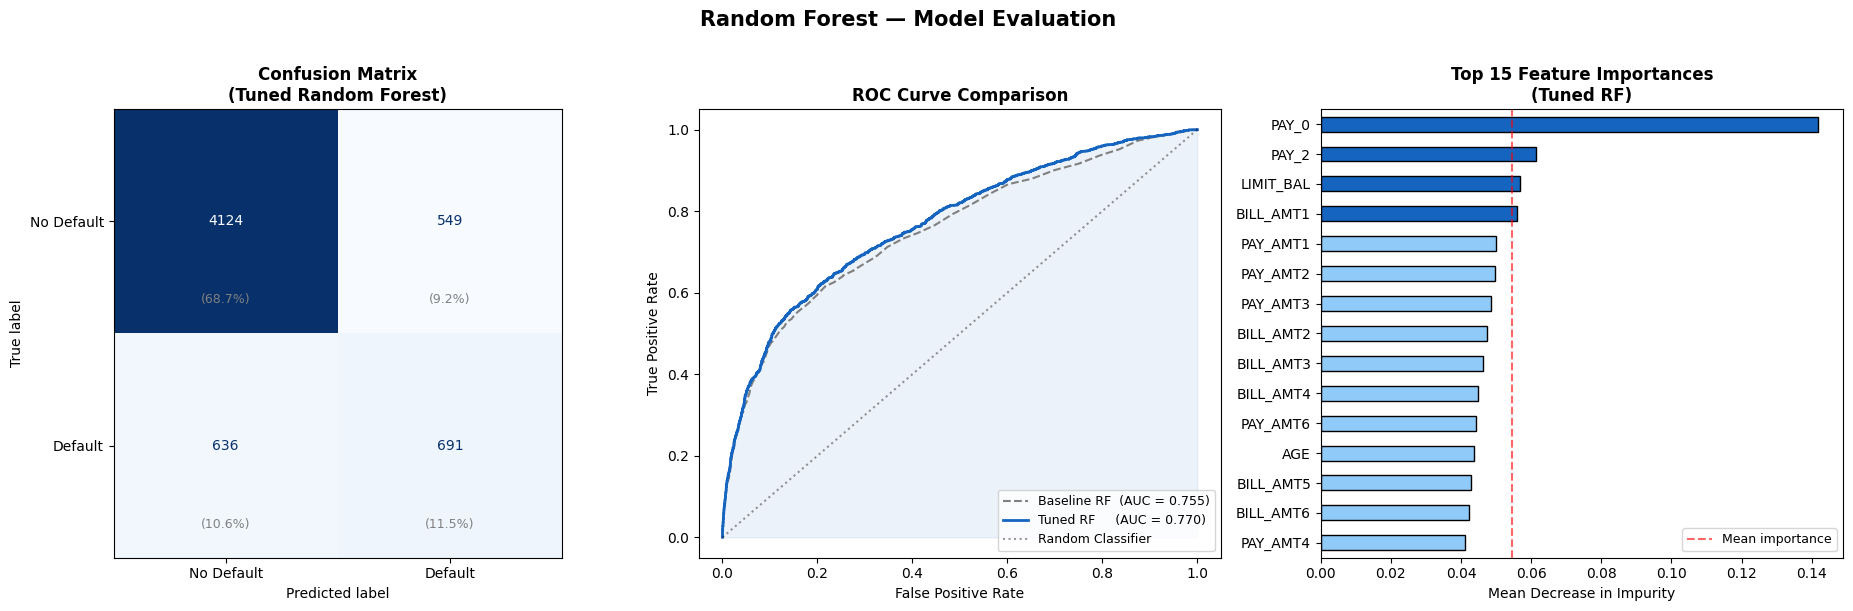

✅ Saved → Desktop/RF_03_evaluation.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# (A) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix\n(Tuned Random Forest)", fontweight="bold")
total = cm.sum()
for (r, c), val in np.ndenumerate(cm):
    axes[0].text(c, r + 0.35, f"({val/total*100:.1f}%)",
                 ha="center", va="center", fontsize=9, color="grey")

# (B) ROC Curve
auc_base = roc_auc_score(y_test, y_prob_base)
auc_tune = roc_auc_score(y_test, y_prob)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr_b, tpr_b, "--", color="gray",
             label=f"Baseline RF  (AUC = {auc_base:.3f})", linewidth=1.5)
axes[1].plot(fpr_t, tpr_t, color="#1565C0",
             label=f"Tuned RF     (AUC = {auc_tune:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], "k:", alpha=0.4, label="Random Classifier")
axes[1].fill_between(fpr_t, tpr_t, alpha=0.08, color="#1565C0")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve Comparison", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=9)

# (C) Top 15 Feature Importances
feat_imp = (pd.Series(best_rf.feature_importances_, index=X.columns)
            .sort_values().tail(15))
colours = ["#1565C0" if v >= feat_imp.quantile(0.75) else "#90CAF9"
           for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=axes[2], color=colours, edgecolor="black")
axes[2].axvline(feat_imp.mean(), color="red", linestyle="--",
                alpha=0.6, label="Mean importance")
axes[2].set_title("Top 15 Feature Importances\n(Tuned RF)", fontweight="bold")
axes[2].set_xlabel("Mean Decrease in Impurity")
axes[2].legend(fontsize=9)

plt.suptitle("Random Forest — Model Evaluation", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DESKTOP, "RF_03_evaluation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Desktop/RF_03_evaluation.png")

In [20]:
def get_metrics(y_true, y_pred_vals, y_prob_vals):
    return {
        "Accuracy"      : round(accuracy_score(y_true, y_pred_vals), 4),
        "Precision (D)" : round(precision_score(y_true, y_pred_vals), 4),
        "Recall (D)"    : round(recall_score(y_true, y_pred_vals), 4),
        "F1-Score (D)"  : round(f1_score(y_true, y_pred_vals), 4),
        "ROC-AUC"       : round(roc_auc_score(y_true, y_prob_vals), 4),
    }

summary = pd.DataFrame({
    "Baseline RF" : get_metrics(y_test, y_pred_base, y_prob_base),
    "Tuned RF"    : get_metrics(y_test, y_pred, y_prob),
})

diff = (summary["Tuned RF"] - summary["Baseline RF"]).round(4)
summary["Improvement"] = diff.apply(
    lambda x: f"▲ +{x}" if x > 0 else (f"▼ {x}" if x < 0 else "—")
)

print("=" * 55)
print("  FINAL SUMMARY TABLE  (D = Default / minority class)")
print("=" * 55)
print(summary.to_string())

summary.to_csv(os.path.join(DESKTOP, "RF_04_summary_table.csv"))
print("\nSaved → Desktop/RF_04_summary_table.csv")
print("\nDone! 4 files on your Desktop:")
print("   RF_01_class_distribution.png")
print("   RF_02_eda.png")
print("   RF_03_evaluation.png")
print("   RF_04_summary_table.csv")

  FINAL SUMMARY TABLE  (D = Default / minority class)
               Baseline RF  Tuned RF Improvement
Accuracy            0.8130    0.8025   ▼ -0.0105
Precision (D)       0.6458    0.5573   ▼ -0.0885
Recall (D)          0.3421    0.5207   ▲ +0.1786
F1-Score (D)        0.4473    0.5384   ▲ +0.0911
ROC-AUC             0.7547    0.7695   ▲ +0.0148

✅ Saved → Desktop/RF_04_summary_table.csv

🎉 Done! 4 files on your Desktop:
   RF_01_class_distribution.png
   RF_02_eda.png
   RF_03_evaluation.png
   RF_04_summary_table.csv
